In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("dataset.csv")

In [3]:
queries = df['query'].values
labels = df['label'].values

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    queries,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

In [6]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [8]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        lowercase=True,
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [9]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

y_val_pred = pipeline.predict(X_val)

print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

              precision    recall  f1-score   support

         llm       0.85      0.96      0.91        55
      search       0.96      0.86      0.91        63

    accuracy                           0.91       118
   macro avg       0.91      0.91      0.91       118
weighted avg       0.91      0.91      0.91       118

[[53  2]
 [ 9 54]]


In [11]:
y_test_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

              precision    recall  f1-score   support

         llm       0.84      0.96      0.90        56
      search       0.96      0.84      0.90        62

    accuracy                           0.90       118
   macro avg       0.90      0.90      0.90       118
weighted avg       0.91      0.90      0.90       118

[[54  2]
 [10 52]]


In [12]:
probs = pipeline.predict_proba(X_test)
max_probs = probs.max(axis=1)

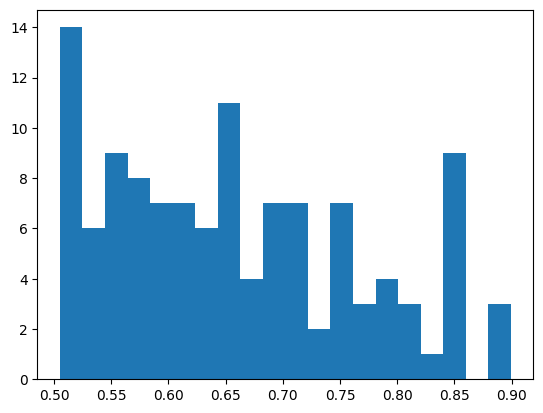

In [13]:
import matplotlib.pyplot as plt
plt.hist(max_probs, bins=20)
plt.show()

In [14]:
import numpy as np

In [15]:
def route_query(query, model, threshold=0.65):
    """
    Returns:
        label: 'search', 'llm', or 'uncertain'
        confidence: probability of chosen class
        probabilities: full class probability dict
    """
    
    probs = model.predict_proba([query])[0]
    classes = model.classes_
    
    max_idx = np.argmax(probs)
    max_prob = probs[max_idx]
    predicted_label = classes[max_idx]
    
    prob_dict = dict(zip(classes, probs))
    
    # if max_prob < threshold:
    #     return "search", max_prob, prob_dict # if unsure, default to search first to reduce unnecessary llm usage and save energy.
    
    return predicted_label, max_prob, prob_dict

In [16]:
label, confidence, probs = route_query(
    "jaime tyrion reddit",
    pipeline,
    threshold=0.70
)

print("Prediction:", label)
print("Confidence:", round(confidence, 3))
print("Probabilities:", probs)

Prediction: search
Confidence: 0.581
Probabilities: {'llm': 0.41868457090988664, 'search': 0.5813154290901134}


In [17]:
import pickle

with open("query_router.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Model saved successfully.")

Model saved successfully.
